## Unsupervised Learning
#### by **Ivan Alducin**
<p><img src="https://cdn.gritglobal.io/uploads/too-broad-customer-segmentation.jpg" width="1000"/></p>

## Segmentacion de Clientes
<p>En esté capitulo nos vamos a enfocar en entender y trabajar un caso de uso para segmentación de clientes, pero antes de eso aquí una pequeña lista de más aplicaciones que se pueden trabajar con los datos recopliados de mis clientes

- Estadística Descriptiva
- Segmentación de Clientes
- Predicción de Abandono
- Valor del Cliente a traves del tiempo (CTLV)

La segmentación la vamos a hacer con base en una metodolgía llamada <b>RFM</b>

</p>

In [109]:
# Importa Pandas, Numpy, Seaborn y Matplotlib
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt
import os
os.chdir("/Users/AlanHDLR/Desktop")

# Importa el archivo "Online Retail.csv"
data = pd.read_csv("M30 Online Retail.csv", encoding='ISO-8859-1')
data

,INVOICE_NO,STOCK_CODE,DESCRIPTION,QUANTITY,INVOICE_DATE,UNIT_PRICE,CUSTOMER_ID,REGION
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01/12/2019 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01/12/2019 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01/12/2019 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01/12/2019 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01/12/2019 08:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,09/12/2020 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,09/12/2020 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,09/12/2020 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,09/12/2020 12:50,4.15,12680.0,France


In [111]:
# Análisis Exploratorio
data.info()
data.describe()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   INVOICE_NO    541909 non-null  str    
 1   STOCK_CODE    541909 non-null  str    
 2   DESCRIPTION   540455 non-null  str    
 3   QUANTITY      541909 non-null  int64  
 4   INVOICE_DATE  541909 non-null  str    
 5   UNIT_PRICE    541909 non-null  float64
 6   CUSTOMER_ID   406829 non-null  float64
 7   REGION        541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 67.8 MB


,QUANTITY,UNIT_PRICE,CUSTOMER_ID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


## Recency
<p>Indicador que nos dice que tan reciente es la compra de un cliente</p>

In [114]:
# Obtener los clientes unicos
customer = data['CUSTOMER_ID'].nunique()
print(f"Hay {customer} clientes únicos")

Hay 4372 clientes únicos


In [116]:
# Obtener la última fecha de compra por cliente
# Modificamos el formato de fecha en el DataFrame original (data)
data['INVOICE_DATE'] = pd.to_datetime(data['INVOICE_DATE'], format='%d/%m/%Y %H:%M')

max_purchase = data.groupby('CUSTOMER_ID')[['INVOICE_DATE']].max()

print(max_purchase)

                   INVOICE_DATE
CUSTOMER_ID                    
12346.0     2020-01-18 10:17:00
12347.0     2020-12-07 15:52:00
12348.0     2020-09-25 13:13:00
12349.0     2020-11-21 09:51:00
12350.0     2020-02-02 16:01:00
...                         ...
18280.0     2020-03-07 09:52:00
18281.0     2020-06-12 10:53:00
18282.0     2020-12-02 11:43:00
18283.0     2020-12-06 12:02:00
18287.0     2020-10-28 09:29:00

[4372 rows x 1 columns]


In [118]:
# Vamos a calcular nuestra metrica de Recency, esto lo haremos restando los días de la última fecha de compra a cada observacón
# Definimos la fecha de hoy (referencia)
fecha_hoy = data['INVOICE_DATE'].max() + pd.Timedelta(days=1)

max_purchase['RECENCY'] = (fecha_hoy - max_purchase['INVOICE_DATE']).dt.days

print(max_purchase.head)

<bound method NDFrame.head of                    INVOICE_DATE  RECENCY
CUSTOMER_ID                             
12346.0     2020-01-18 10:17:00      327
12347.0     2020-12-07 15:52:00        2
12348.0     2020-09-25 13:13:00       75
12349.0     2020-11-21 09:51:00       19
12350.0     2020-02-02 16:01:00      311
...                         ...      ...
18280.0     2020-03-07 09:52:00      278
18281.0     2020-06-12 10:53:00      181
18282.0     2020-12-02 11:43:00        8
18283.0     2020-12-06 12:02:00        4
18287.0     2020-10-28 09:29:00       43

[4372 rows x 2 columns]>


In [120]:
# Unir el DataFrame de clientes únicos con el que acabamos de crear de la última fecha de compra
customer = pd.merge(data[['CUSTOMER_ID']].drop_duplicates(), max_purchase, on='CUSTOMER_ID')

(array([946., 575., 412., 272., 269., 260., 167., 103.,  91.,  77.,  84.,
         66.,  82.,  74.,  72.,  71.,  58.,  65.,  53.,  69.,  61.,  67.,
         52.,  45.,  51.,  56.,  38.,   8.,  40.,  88.]),
 array([  1.        ,  13.46666667,  25.93333333,  38.4       ,
         50.86666667,  63.33333333,  75.8       ,  88.26666667,
        100.73333333, 113.2       , 125.66666667, 138.13333333,
        150.6       , 163.06666667, 175.53333333, 188.        ,
        200.46666667, 212.93333333, 225.4       , 237.86666667,
        250.33333333, 262.8       , 275.26666667, 287.73333333,
        300.2       , 312.66666667, 325.13333333, 337.6       ,
        350.06666667, 362.53333333, 375.        ]),
 <BarContainer object of 30 artists>)

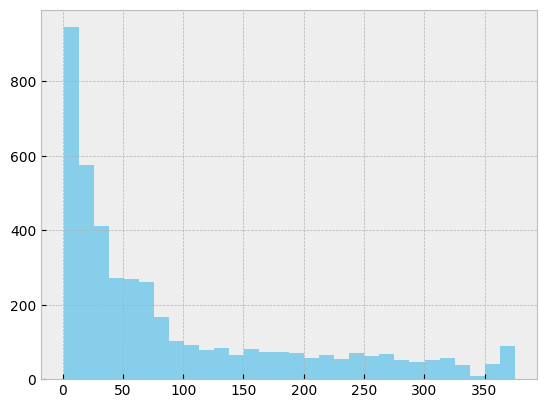

In [122]:
# Grafica un histograma de Recency
plt.hist(customer['RECENCY'], bins=30, color='skyblue')

In [124]:
# Imprime la Estadística de Resumen para Recency
print(customer['RECENCY'].describe())

count    4372.000000
mean       92.123056
std       100.946554
min         1.000000
25%        17.000000
50%        50.000000
75%       143.000000
max       375.000000
Name: RECENCY, dtype: float64


## Frequency
<p>Frecuencia con la que un cliente compra uno o más productos</p>

In [127]:
# Obtener el número de compras por cliente
frequency = data.groupby('CUSTOMER_ID')[['INVOICE_NO']].nunique()
frequency.columns = ['FREQUENCY']
print(frequency)

             FREQUENCY
CUSTOMER_ID           
12346.0              2
12347.0              7
12348.0              4
12349.0              1
12350.0              1
...                ...
18280.0              1
18281.0              1
18282.0              3
18283.0             16
18287.0              3

[4372 rows x 1 columns]


In [129]:
# Unir el DataFrame que acabamos de crear con el de los clientes unicos
customer = pd.merge(customer, frequency, on='CUSTOMER_ID')

(array([3.835e+03, 3.430e+02, 9.400e+01, 4.700e+01, 1.900e+01, 1.000e+01,
        8.000e+00, 4.000e+00, 1.000e+00, 3.000e+00, 2.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 2.000e+00, 1.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 1.000e+00]),
 array([  1.        ,   9.23333333,  17.46666667,  25.7       ,
         33.93333333,  42.16666667,  50.4       ,  58.63333333,
         66.86666667,  75.1       ,  83.33333333,  91.56666667,
         99.8       , 108.03333333, 116.26666667, 124.5       ,
        132.73333333, 140.96666667, 149.2       , 157.43333333,
        165.66666667, 173.9       , 182.13333333, 190.36666667,
        198.6       , 206.83333333, 215.06666667, 223.3       ,
        231.53333333, 239.76666667, 248.        ]),
 <BarContainer object of 30 artists>)

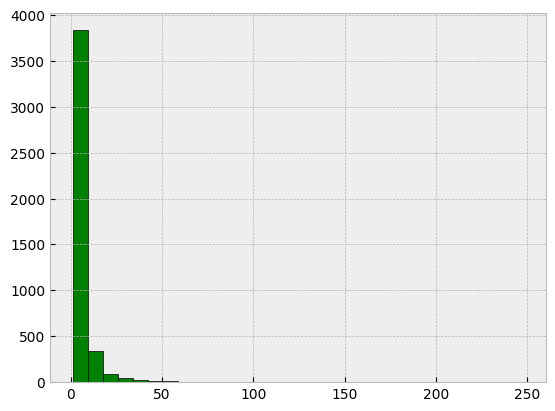

In [131]:
# Grafica un histograma de Frequency
plt.hist(customer['FREQUENCY'], bins=30, color='green', edgecolor='black')

In [133]:
# Imprime la Estadística de Resumen para Frequency
print(customer['FREQUENCY'].describe())

count    4372.000000
mean        5.075480
std         9.338754
min         1.000000
25%         1.000000
50%         3.000000
75%         5.000000
max       248.000000
Name: FREQUENCY, dtype: float64


## Monetary
<p>Valor del monto total que ha gastado un cliente en la compra de mis productos</p>

In [136]:
# Calcular el monto total por cada compra
data['MONETARY'] = data['QUANTITY'] * data['UNIT_PRICE']

# Obtener el valor monetario de compra por cliente
monetary = data.groupby('CUSTOMER_ID')[['MONETARY']].sum().reset_index()

In [138]:
# Unir el DataFrame que acabamos de crear con el de los clientes unicos
customer = pd.merge(customer, monetary, on='CUSTOMER_ID')
customer

,CUSTOMER_ID,INVOICE_DATE,RECENCY,FREQUENCY,MONETARY
0,17850.0,2020-02-10 14:38:00,303,35,5288.63
1,13047.0,2020-11-08 12:10:00,32,18,3079.10
2,12583.0,2020-12-07 08:07:00,3,18,7187.34
3,13748.0,2020-09-05 09:45:00,96,5,948.25
4,15100.0,2020-01-13 17:09:00,331,6,635.10
...,...,...,...,...,...
4367,13436.0,2020-12-08 10:33:00,2,1,196.89
4368,15520.0,2020-12-08 10:58:00,2,1,343.50
4369,13298.0,2020-12-08 13:11:00,1,1,360.00
4370,14569.0,2020-12-08 14:58:00,1,1,227.39


(array([3.126e+03, 1.094e+03, 8.700e+01, 2.200e+01, 9.000e+00, 8.000e+00,
        6.000e+00, 2.000e+00, 0.000e+00, 4.000e+00, 4.000e+00, 2.000e+00,
        1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 1.000e+00, 0.000e+00,
        1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 1.000e+00]),
 array([ -4287.63 ,   1387.903,   7063.436,  12738.969,  18414.502,
         24090.035,  29765.568,  35441.101,  41116.634,  46792.167,
         52467.7  ,  58143.233,  63818.766,  69494.299,  75169.832,
         80845.365,  86520.898,  92196.431,  97871.964, 103547.497,
        109223.03 , 114898.563, 120574.096, 126249.629, 131925.162,
        137600.695, 143276.228, 1489

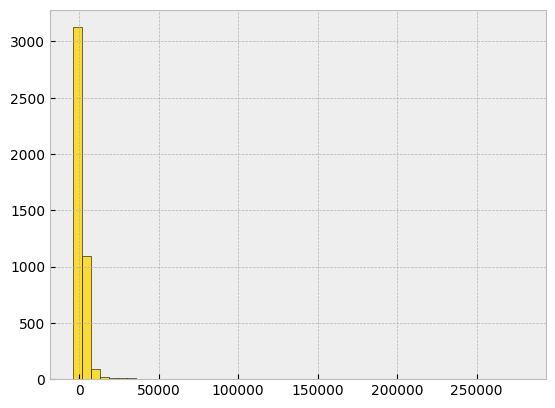

In [140]:
# Grafica un histograma de Monetary
plt.hist(customer['MONETARY'], bins=50, color='gold', edgecolor='black', alpha=0.8)

In [142]:
# Imprime la Estadística de Resumen para Monetary
print(customer['MONETARY'].describe())

count      4372.000000
mean       1898.459701
std        8219.345141
min       -4287.630000
25%         293.362500
50%         648.075000
75%        1611.725000
max      279489.020000
Name: MONETARY, dtype: float64


## Algoritmo k-Means
<p>Ya creamos nuestros indicadores principales de la metodología RFM. es hora de hacer <i>Machine Learning</i>. Para ello utilizaremos un algoritmo no supervisado llamado <b>k-Means</b></p>
<p><img src="https://miro.medium.com/max/818/1*fG8u8nV7qR91wDyFDEEV-g.png" width="250"/></p>

In [145]:
# Funcion para ordenar los clusters
def order_cluster(cluster_field_name, target_field_name, df, ascending):
    new_cluster_field_name = 'new_' + cluster_field_name
    df_new = df.groupby(cluster_field_name)[target_field_name].mean().reset_index()
    df_new = df_new.sort_values(by=target_field_name,ascending=ascending).reset_index(drop=True)
    df_new['index'] = df_new.index
    df_final = pd.merge(df,df_new[[cluster_field_name,'index']], on=cluster_field_name)
    df_final = df_final.drop([cluster_field_name],axis=1)
    df_final = df_final.rename(columns={"index":cluster_field_name})
    return df_final

## Elbow Method
<p>¿Cual es mi número óptimo de clusters? Vamos a contruir una <i>gráfica de codo</i> para averiguarlo</p>

In [148]:
# Importa la librería de kMeans
from sklearn.cluster import KMeans

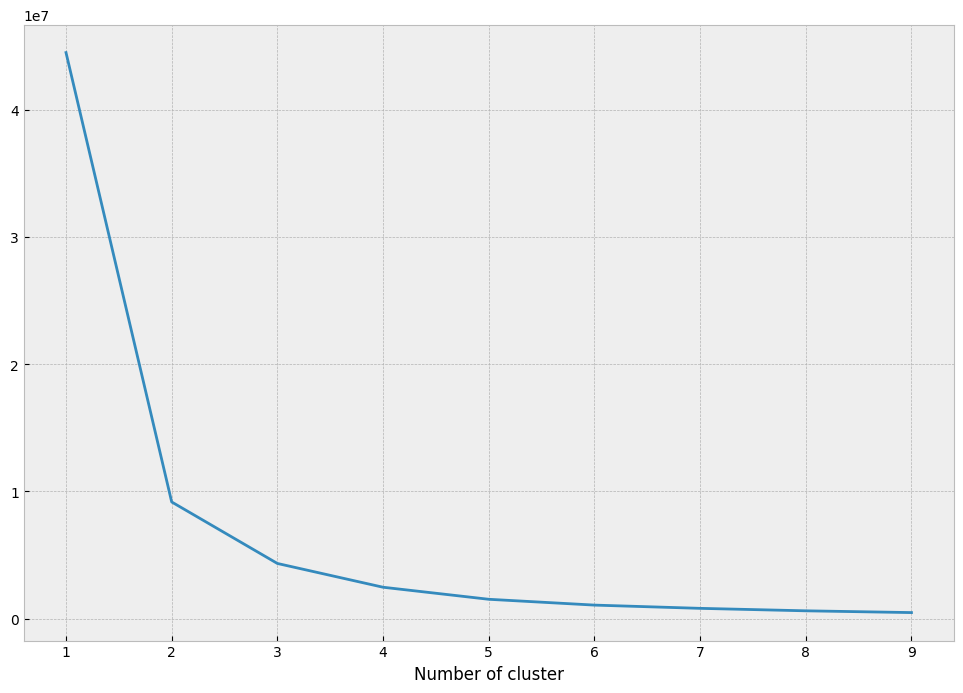

In [150]:
# Configuración inicial - Vamos a tomar como referencia el indicador de Recency
sse={}
recency = customer[['RECENCY']]

for k in range(1, 10):
    # Instancia el algoritmo de k-means iterando sobre k
    kmeans = KMeans(n_clusters=k, max_iter=1000, n_init=10)
    
    # Entrena el algoritmo
    kmeans.fit(recency)
    
    # Adjunta las etiquetas
    recency["clusters"] = kmeans.labels_
    
    # Adunta la inercia o variación al arreglo sse
    sse[k] = kmeans.inertia_
    
# Grafico de codo (Elbow)
plt.figure(figsize=(12,8))
plt.plot(list(sse.keys()), list(sse.values()))
plt.xlabel("Number of cluster")
plt.show()

In [152]:
# Instanciar el algoritmo con 4 clusters para Recency 
kmeans = KMeans(n_clusters=4, max_iter=1000, n_init=10)

# Entrenar el algoritmo
kmeans.fit(customer[['RECENCY']])

# Obtener las predicciones
customer['RECENCY_CLUSTER'] = kmeans.predict(customer[['RECENCY']])

# Ordenar los clusters
customer = order_cluster('RECENCY_CLUSTER', 'RECENCY', customer, False)

# Estadística Descriptiva del cluster creado
customer.groupby('RECENCY_CLUSTER')['RECENCY'].describe()

,count,mean,std,min,25%,50%,75%,max
RECENCY_CLUSTER,,,,,,,,
0,506.0,310.507905,39.519001,251.0,275.0,307.0,352.75,375.0
1,622.0,190.889068,32.715170,137.0,163.0,189.0,218.00,250.0
2,1039.0,81.654475,23.825978,51.0,62.0,75.0,98.50,136.0
3,2205.0,19.080726,13.825980,1.0,8.0,17.0,29.00,50.0


In [154]:
# Instanciar el algoritmo con 4 clusters para Frequency 
kmeans = KMeans(n_clusters=4, max_iter=1000, n_init=10)

# Entrenar el algoritmo
kmeans.fit(customer[['FREQUENCY']])

# Obtener las predicciones
customer['FREQUENCY_CLUSTER'] = kmeans.predict(customer[['FREQUENCY']])

# Ordenar los clusters
customer = order_cluster('FREQUENCY_CLUSTER', 'FREQUENCY', customer, True)

# Estadística Descriptiva de los clusters
customer.groupby('FREQUENCY_CLUSTER')['FREQUENCY'].describe()

,count,mean,std,min,25%,50%,75%,max
FREQUENCY_CLUSTER,,,,,,,,
0,3755.0,2.816511,1.976997,1.0,1.0,2.0,4.00,8.0
1,561.0,14.604278,5.615373,9.0,10.0,13.0,17.00,31.0
2,50.0,48.320000,14.876965,32.0,36.5,43.0,53.75,89.0
3,6.0,167.500000,56.807570,118.0,120.5,148.5,210.25,248.0


In [156]:
# Instanciar el algoritmo con 4 clusters para Monetary 
kmeans = KMeans(n_clusters=4, max_iter=1000, n_init=10)

# Entrenar el algoritmo
kmeans.fit(customer[['MONETARY']])

# Obtener las predicciones
customer['MONETARY_CLUSTER'] = kmeans.predict(customer[['MONETARY']])

# Ordenar los clusters ¿Como tienes que ordenar el cluster?
customer = order_cluster('MONETARY_CLUSTER', 'MONETARY', customer, True)

# Estadística Descriptiva de los clusters
customer.groupby('MONETARY_CLUSTER')['MONETARY'].describe()

,count,mean,std,min,25%,50%,75%,max
MONETARY_CLUSTER,,,,,,,,
0,4252.0,1160.746285,1403.441736,-4287.63,286.565,623.575,1476.0700,8257.04
1,102.0,15390.295980,7557.269118,8393.22,10192.235,12395.080,17460.8075,40340.78
2,15.0,71423.516000,28632.631870,50415.49,52287.280,57385.880,77008.7300,132572.62
3,3.0,241136.560000,47874.073443,187482.17,221960.330,256438.490,267963.7550,279489.02


## Score de Segmentación
<p>El algoritmo de k-means nos da una segmentación generalizada, pero podemos personalizarla aún más creando una métrica que asigne una calificación al valor del cluster. Esto es lo que vamos a hacer!!</p>

In [159]:
# Vamos a crear nuestro score sumando el valor de cada uno de los clusters
customer['SCORE'] = customer['RECENCY_CLUSTER'] + customer['FREQUENCY_CLUSTER'] + customer['MONETARY_CLUSTER']

# Obtener el promedio para cada una de las métricas de las calificaciones creadas (Score)
customer.groupby('SCORE')[['RECENCY', 'FREQUENCY', 'MONETARY']].mean()

,RECENCY,FREQUENCY,MONETARY
SCORE,,,
0,310.701789,1.427435,329.120239
1,191.269608,2.114379,521.434348
2,83.494024,2.798805,915.587492
3,22.740807,3.787663,1137.150196
4,14.106904,13.964365,3788.915880
5,9.771429,24.300000,12741.666286
6,4.741935,44.451613,25862.682581
7,6.545455,86.818182,55567.717273
8,2.666667,113.000000,162131.253333


In [161]:
# Crea una funcion que asigne lo siguiente: 
# Si score <= 1 entonces 'Low-Value', si score >1 y <=4 entonces 'Average', si score >4 y <=6 entonces 'Potential', por último si score >6 entonces 'High-Value'
def segment(score):
    if score <= 1:
        return 'Low-Value'
    elif score <= 4:
        return 'Average'
    elif score <= 6:
        return 'Potential'
    else:
        return 'High-Value'

# Crear una columna aplicando esta función al campo 'SCORE'
customer['SEGMENT'] = customer['SCORE'].apply(segment)


In [163]:
# Vamos a dar un vistazo a la tabla final
customer.head()

,CUSTOMER_ID,INVOICE_DATE,RECENCY,FREQUENCY,MONETARY,RECENCY_CLUSTER,FREQUENCY_CLUSTER,MONETARY_CLUSTER,SCORE,SEGMENT
0,17850.0,2020-02-10 14:38:00,303,35,5288.63,0,2,0,2,Average
1,13047.0,2020-11-08 12:10:00,32,18,3079.10,3,1,0,4,Average
2,12583.0,2020-12-07 08:07:00,3,18,7187.34,3,1,0,4,Average
3,13748.0,2020-09-05 09:45:00,96,5,948.25,2,0,0,2,Average
4,15100.0,2020-01-13 17:09:00,331,6,635.10,0,0,0,0,Low-Value


In [165]:
# Imprime la proporción o el total de clientes por segmento
print("Total de clientes por segmento:")
print(customer['SEGMENT'].value_counts())


Total de clientes por segmento:
SEGMENT
Average       3139
Low-Value     1115
Potential      101
High-Value      17
Name: count, dtype: int64


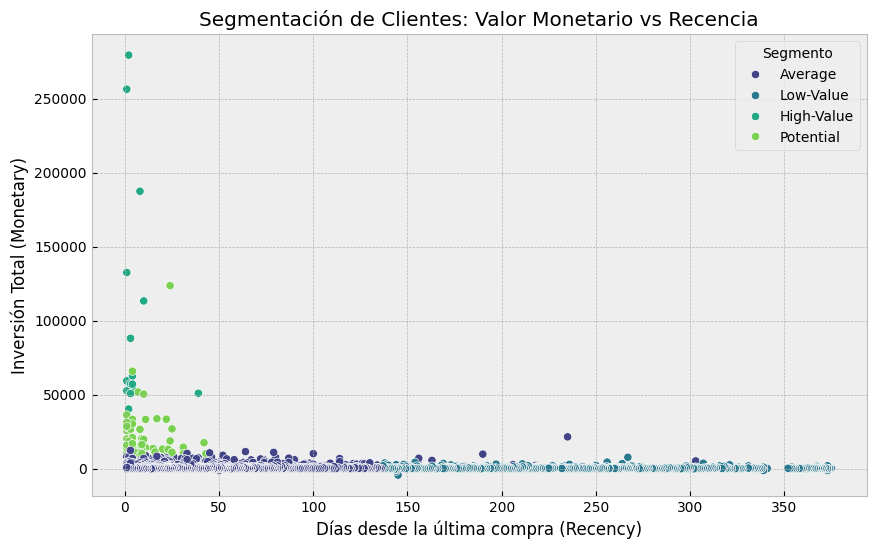

In [167]:
# Define un estilo 'bmh'
plt.style.use('bmh')

# Filtra los valores para RECENCY < 4000
customer = customer[customer['RECENCY'] < 4000]

# Crea un grafico de dispersion de 'MONETARY' VS 'RECENCY' por Segmento
plt.figure(figsize=(10, 6))
sb.scatterplot(x='RECENCY', y='MONETARY', hue='SEGMENT', data=customer, palette='viridis')
plt.title('Segmentación de Clientes: Valor Monetario vs Recencia')
plt.xlabel('Días desde la última compra (Recency)')
plt.ylabel('Inversión Total (Monetary)')
plt.legend(title='Segmento')
plt.show()


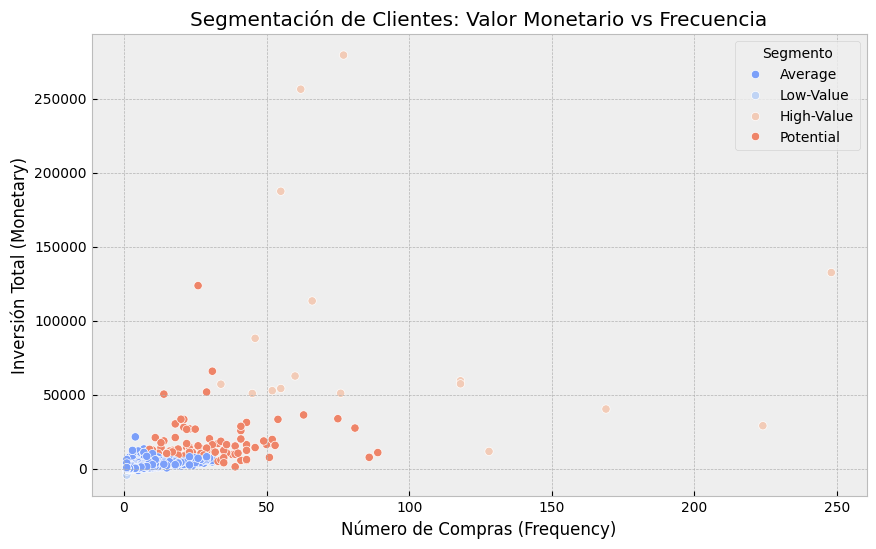

In [169]:
# Crea un grafico de dispersion de 'MONETARY' vs 'FREQUENCY' vs  por Segmento
plt.figure(figsize=(10, 6))
sb.scatterplot(x='FREQUENCY', y='MONETARY', hue='SEGMENT', data=customer, palette='coolwarm')

# 2. Personalización del gráfico
plt.title('Segmentación de Clientes: Valor Monetario vs Frecuencia')
plt.xlabel('Número de Compras (Frequency)')
plt.ylabel('Inversión Total (Monetary)')

# 3. Escala logarítmica (Opcional, muy recomendada si hay mucha diferencia en el gasto)
# plt.yscale('log') 

plt.legend(title='Segmento')
plt.show()



